In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [4]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df['Age'].fillna(df['Age'].median(), inplace=True)

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df.drop('Cabin', axis=1, inplace=True)

/tmp/ipykernel_6500/792774890.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_6500/792774890.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [6]:
df['Sex'] = df['Sex'].map({'male':0,'female':1})

df['Embarked'] = df['Embarked'].map({
    'S':0,
    'C':1,
    'Q':2
})

In [7]:
X = df[['Pclass','Sex','Age','Fare','SibSp','Parch']]

y = df['Survived']

In [8]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = DecisionTreeClassifier()

model.fit(X_train,y_train)

DecisionTreeClassifier()

In [10]:
predictions = model.predict(X_test)

In [12]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:",accuracy)

Accuracy: 0.7653631284916201


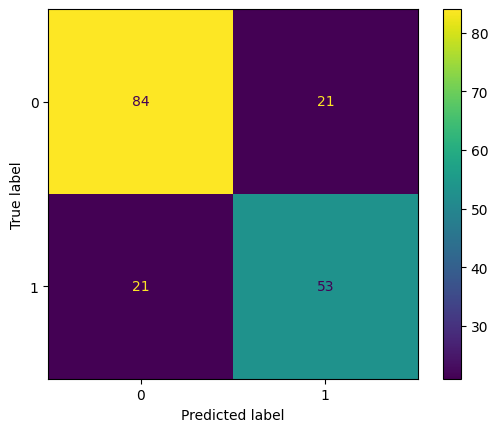

In [13]:
cm = confusion_matrix(
    y_test,
    predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

display.plot()

plt.show()

In [14]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':model.feature_importances_
})

print(
    importance.sort_values(
        by='Importance',
        ascending=False
    )
)

  Feature  Importance
1     Sex    0.310280
3    Fare    0.282548
2     Age    0.196664
0  Pclass    0.122884
4   SibSp    0.051308
5   Parch    0.036316
